# Calibrate Intergrowth Hard/Normal Morphology

Calibrate a local-window morphology classifier that turns metallic ore masks into a parallel intergrowth mask: background, talc, normal ore, hard ore, and ignore. Talc remains manual/reviewed only; this notebook does not create talc from RGB/HSV thresholds.

In [ ]:
from pathlib import Path
import json
import sys

from PIL import Image
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from ore_detection.data.inventory import inventory_baseline_images
from ore_detection.backend.ui_annotation import BASE_UI_CLASSES, class_index_to_color_image
from ore_detection.descriptors.intergrowth_classification import (
    IntergrowthClassifierConfig,
    choose_hard_threshold,
    classify_intergrowth_mask,
    save_intergrowth_classifier_config,
)

BASELINE_ROOT = PROJECT_ROOT / 'datasets' / 'baseline'
PREDICTION_ROOT = PROJECT_ROOT / 'data_work' / 'predictions' / 'model_segmentation' / 'baseline_crops'
CLASSIFIER_PATH = PROJECT_ROOT / 'models' / 'intergrowth_classifier' / '001' / 'classifier.json'

RUN_CALIBRATION = True
WINDOW_SIZE = 128
STRIDE = 64
SMALL_AREA_THRESHOLD = 25
DEFAULT_HARD_THRESHOLD = 0.5
EFFECTIVE_STRIDE = min(STRIDE, WINDOW_SIZE)

print(f'baseline root: {BASELINE_ROOT}')
print(f'classifier path: {CLASSIFIER_PATH}')
print(f'window size: {WINDOW_SIZE}; requested stride: {STRIDE}; effective stride: {EFFECTIVE_STRIDE}')

baseline root: C:\Users\Cape\PycharmProjects\ore_detection\datasets\baseline
classifier path: C:\Users\Cape\PycharmProjects\ore_detection\models\intergrowth_classifier\001\classifier.json
window size: 128; requested stride: 64; effective stride: 64


The first calibration pass uses weak crop labels from `Normal ore` and `Hard ore`. `Talc contained` crops are reported as diagnostics only because talc is a separate manual class and the metallic ore pixels still need reviewed normal/hard labels.

In [2]:
baseline_records = inventory_baseline_images(BASELINE_ROOT)
label_counts = {}
for record in baseline_records:
    label_counts[str(record['label'])] = label_counts.get(str(record['label']), 0) + 1
print(label_counts)

{'Hard ore': 486, 'Normal ore': 565, 'Talc contained': 171}


For each prediction directory, load `ore_mask.png` and summarize local intergrowth scores. This notebook expects baseline crop predictions to already exist from `04_predict_ore_masks_and_descriptors.ipynb`; prediction generation stays disabled here by default.

In [3]:
def prediction_dir_for_record(record):
    sample_id = f"{record['part']}_{record['label']}_{Path(record['path']).stem}".replace(' ', '_')
    return PREDICTION_ROOT / sample_id

def image_score_from_prediction(prediction_dir, config):
    with Image.open(prediction_dir / 'ore_mask.png') as mask:
        result = classify_intergrowth_mask(mask, config=config)
    return result.metrics['hard_fraction_of_metallic_ore']

config = IntergrowthClassifierConfig(
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    small_area_threshold=SMALL_AREA_THRESHOLD,
    hard_threshold=DEFAULT_HARD_THRESHOLD,
)

labeled_scores = []
diagnostic_scores = []
matched_prediction_counts = {}
missing_prediction_counts = {}
if RUN_CALIBRATION:
    for record in baseline_records:
        prediction_dir = prediction_dir_for_record(record)
        label = str(record['label'])
        if not (prediction_dir / 'ore_mask.png').exists():
            missing_prediction_counts[label] = missing_prediction_counts.get(label, 0) + 1
            continue
        score = image_score_from_prediction(prediction_dir, config)
        matched_prediction_counts[label] = matched_prediction_counts.get(label, 0) + 1
        if label in {'Normal ore', 'Hard ore'}:
            labeled_scores.append((score, label))
        else:
            diagnostic_scores.append((score, label, record['path']))

    print('matched prediction counts:', matched_prediction_counts)
    print('missing prediction counts:', missing_prediction_counts)
    labels_with_scores = {label for _, label in labeled_scores}
    if not {'Normal ore', 'Hard ore'} <= labels_with_scores:
        print('Need both Normal ore and Hard ore prediction masks before saving a calibrated threshold.')
        print('Classifier not saved; current config remains diagnostic only:')
        print(json.dumps(config.to_dict(), indent=2))
    else:
        threshold = choose_hard_threshold(labeled_scores)
        calibrated = IntergrowthClassifierConfig.from_dict({**config.to_dict(), 'hard_threshold': threshold['threshold']})
        save_intergrowth_classifier_config(calibrated, CLASSIFIER_PATH)
        print(json.dumps(threshold, indent=2))
        print(f'saved: {CLASSIFIER_PATH}')
else:
    print('Set RUN_CALIBRATION = True after baseline Normal ore and Hard ore predictions exist.')

Set RUN_CALIBRATION = True after baseline Normal ore and Hard ore predictions exist.


## Visual Review

Review raw image, binary ore overlay, binary ore mask, predicted intergrowth mask, and hard-score map. This block does not save artifacts; it lets you check the local morphology classifier by eye before accepting thresholds.

prediction dirs available for visual review: 25


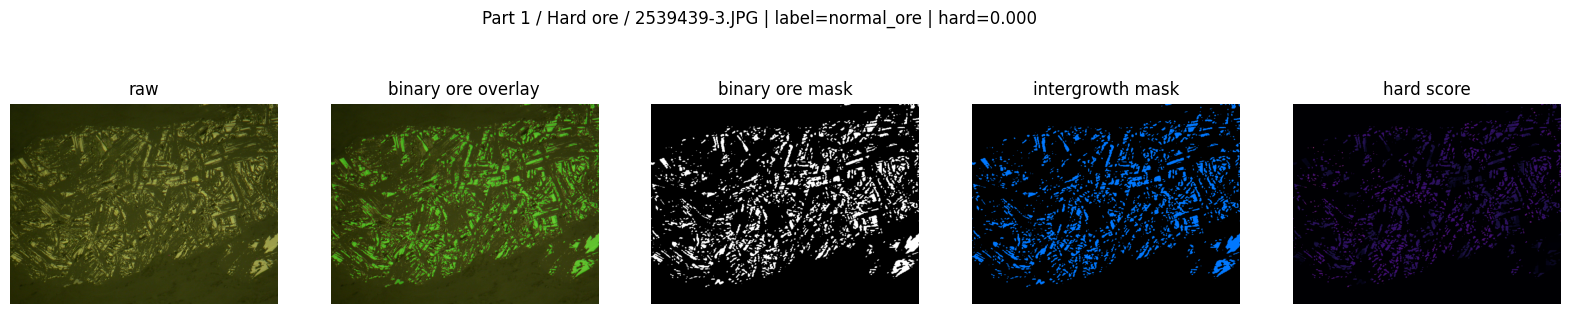

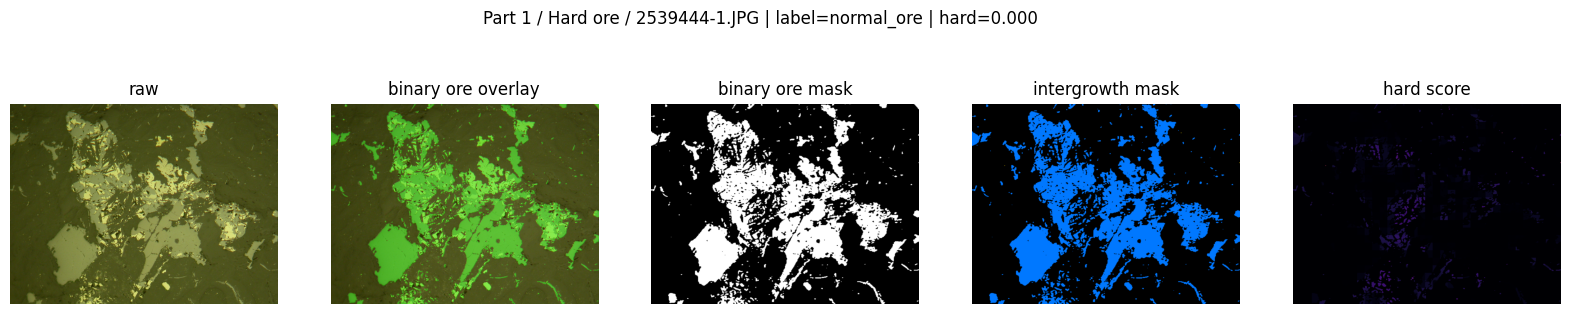

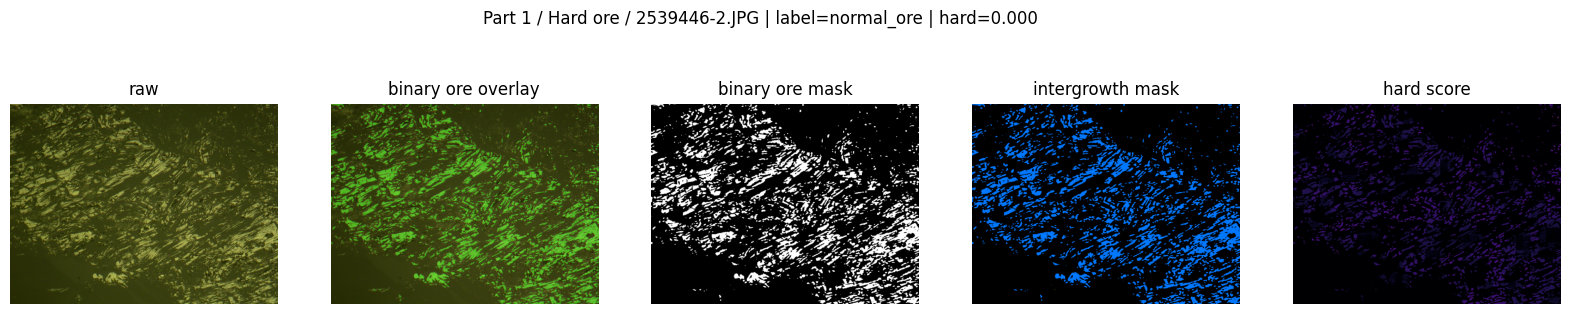

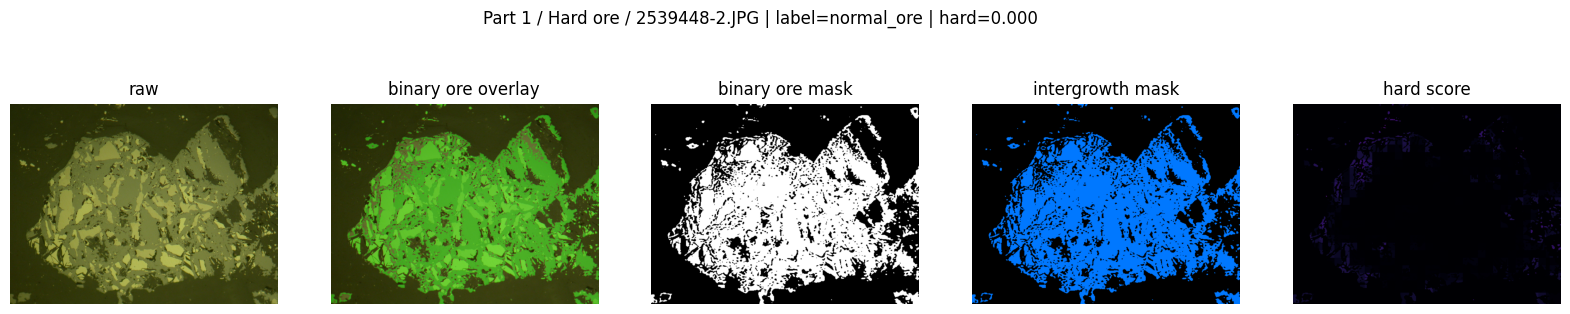

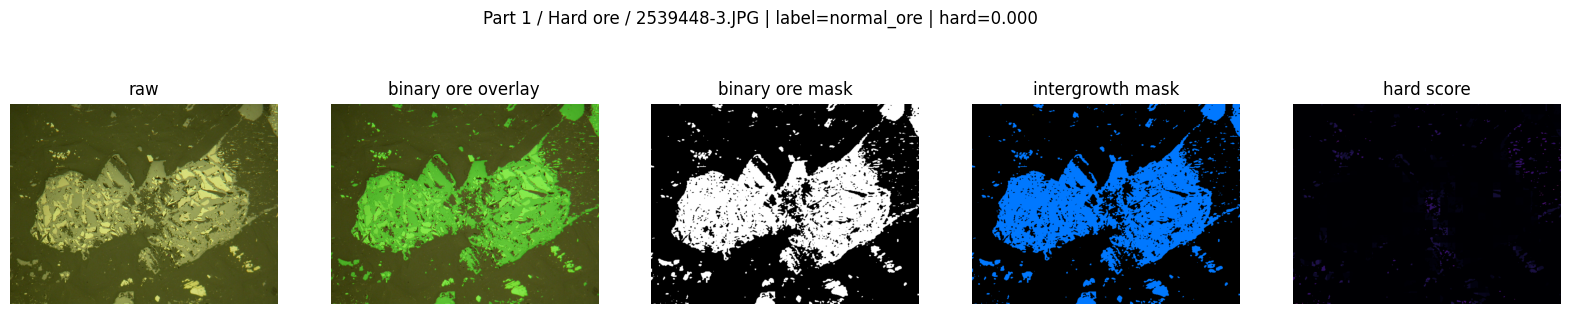

In [4]:
REVIEW_LIMIT = 5

review_records = []
for record in baseline_records:
    prediction_dir = prediction_dir_for_record(record)
    if (prediction_dir / 'ore_mask.png').exists():
        review_records.append((record, prediction_dir))

print(f'prediction dirs available for visual review: {len(review_records)}')

for record, sample_dir in review_records[:REVIEW_LIMIT]:
    metadata_path = sample_dir / 'metadata.json'
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
        image_path = Path(metadata.get('image_path', record['path']))
    else:
        image_path = Path(record['path'])

    overlay_path = sample_dir / 'overlay.png'
    with Image.open(image_path) as raw, Image.open(sample_dir / 'ore_mask.png') as mask:
        result = classify_intergrowth_mask(mask, config=config)
        intergrowth_preview = class_index_to_color_image(result.intergrowth_mask, classes=BASE_UI_CLASSES)
        overlay = Image.open(overlay_path).convert('RGB') if overlay_path.exists() else None
        column_count = 5 if overlay is not None else 4
        fig, axes = plt.subplots(1, column_count, figsize=(4 * column_count, 4))
        axes[0].imshow(raw.convert('RGB'))
        axes[0].set_title('raw')
        column = 1
        if overlay is not None:
            axes[column].imshow(overlay)
            axes[column].set_title('binary ore overlay')
            overlay.close()
            column += 1
        axes[column].imshow(mask.convert('L'), cmap='gray')
        axes[column].set_title('binary ore mask')
        column += 1
        axes[column].imshow(intergrowth_preview)
        axes[column].set_title('intergrowth mask')
        column += 1
        axes[column].imshow(result.score, cmap='magma', vmin=0, vmax=255)
        axes[column].set_title('hard score')
        fig.suptitle(
            f"{record['part']} / {record['label']} / {Path(record['path']).name} | "
            f"label={result.metrics['image_label']} | "
            f"hard={result.metrics['hard_fraction_of_metallic_ore']:.3f}"
        )
        for ax in axes:
            ax.axis('off')
        plt.show()